<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionalesI2025/blob/main/Semana4/DescensoGradiente1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import copy

In [120]:
def Plotter(e):

  fig = plt.figure(figsize=(8,3))
  ax =fig.add_subplot(121)
  ax1 =fig.add_subplot(122)
  ax.set_title('Epoch: {:.0f}'.format(e),fontsize=10)

  return ax,ax1

(<Axes: title={'center': 'Epoch: 10'}>, <Axes: >)

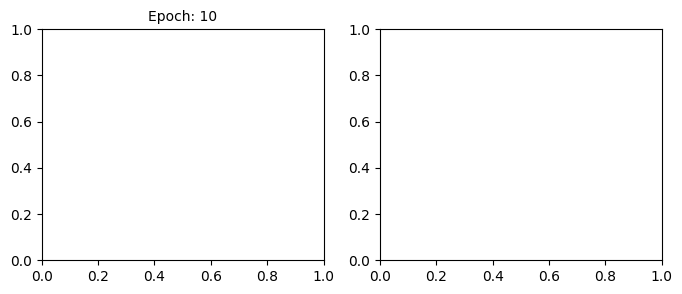

In [121]:
Plotter(10)

In [122]:
def f(x):
  return x**2 + 10*np.sin(x)

In [123]:
xvalues = np.linspace(-10,10,50)
yvalues = f(xvalues)

In [124]:
def Derivative(f,x,h=1e-5):
  return (f(x+h)-f(x-h))/(2*h)

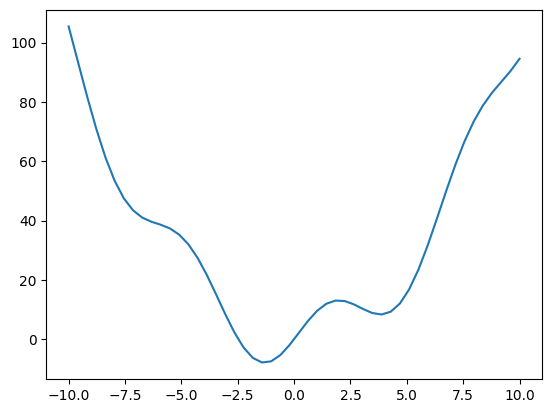

In [125]:
plt.plot(xvalues,yvalues)

In [126]:
def GradientDescent(f,epochs=100,lr=0.05):

  # Semilla
  xn = np.random.randint(-20,20,10)

  # Guadamos el valor de la funcion
  fxn = f(xn)

  # Vamos a guardar en una estrucutra de datos stack
  History = np.array([f(xn)])

  for e in range(epochs):

    # Algoritmo
    xn1 = xn - lr*Derivative(f,xn) # descenso para minimizar
    # Actualizamos
    xn = xn1

    History = np.vstack((History,f(xn)))

    clear_output(wait=True)

    #ax,ax1 = Plotter(e)
    #ax.plot(xvalues,yvalues)
    #ax.scatter(xn,f(xn),color='red')
    #ax1.plot(History[:e,:])
    #plt.show()

    print(xn)
    # Calculamos la diferencia entre iteraciones consecutivas
    tolerancia = np.abs( History[-1] - History[-2] )
    print(tolerancia)

    time.sleep(0.01)

    # Criterior de parada
    if np.all( tolerancia < 1e-5 ):
      print('final:',e)
      break

  return xn

In [127]:
xn = GradientDescent(f,epochs=1000,lr=0.01)

[-1.3064631  -1.3087681  -1.30776565 -1.30661876  3.83752201 -1.30644
  3.83727651 -1.30644     3.83763874  3.83752201]
[8.73852102e-10 8.88512599e-06 2.88004147e-06 5.23479367e-08
 2.43487541e-09 1.77635684e-15 2.93377127e-08 1.77635684e-15
 2.38015119e-08 2.43487541e-09]
final: 163


In [116]:
xn

array([-1.30659983,  3.83744933, -1.30718373, -1.30644001, -1.30644001,
        3.8374672 , -1.30652206, -1.30648674,  3.83746922, -1.3066602 ])